# AI-assisted workflow

This notebook repeats the workflow of this week’s lesson, but this time an
AI assistant helps us write the code. The division of labour is simple:

- **You decide the GIS part**: which data, which coordinate reference system,
  which spatial predicate, which classes. You are the GIS expert, and these
  decisions go *into* your prompt.
- **The AI assistant helps with the Python part**: boilerplate, syntax you
  don’t remember, restructuring code, explaining error messages.

The responses shown below are *examples*. If you run the same prompts yourself,
you will get different code, and that is fine. What matters is that you can
read the code, run it, and check the result.

This week, we use an AI assistant to turn the step-by-step workflow of the
network analysis lesson into *reusable functions*, and then reuse them for a
different area.

> **Habit of the week: turn working code into functions**
>
> A notebook that works for one area is a good start. Functions turn it into a
> tool you can apply to *any* area, which is what ‘automating GIS processes’ is
> about. Restructuring existing code is a task where AI assistants are
> particularly helpful, because the working code already tells them what to do.
> Your job is to make sure the functions still do the same thing as before.

## Your decisions

- Travel mode: **bike**.
- Network extent: the area of interest, plus a **200 m buffer**, so that routes can leave the area slightly.
- Distances are computed in **ETRS-TM35FIN (EPSG:3067)**, in metres.
- The route length is measured along the actual street segments.
- Origin and destination are given as place names, and geocoded with OSMnx, as in the lesson.

In [1]:
import osmnx
print(f"osmnx {osmnx.__version__}")

osmnx 2.1.1


## Step 1: from notebook cells to functions

**Prompt:**

```text
I use osmnx 2.x and geopandas 1.x. Turn the following steps from my notebook
into two functions with docstrings:

1. get_network(place_name, network_type="bike", buffer_m=200): geocode the
   place to a polygon, buffer it by buffer_m metres (buffer in EPSG:3067),
   download the network for the buffered polygon, and return the graph
   projected to EPSG:3067.
2. shortest_route(graph, origin_name, destination_name): geocode both places
   (use the centroid), find the nearest network nodes, compute the shortest
   path by length, and return a GeoDataFrame with one row: columns "origin",
   "destination", "length_m" (length along the street segments) and the route
   geometry, in the CRS of the graph.

[... pasted code from the lesson ...]
```

**Example response** (yours may differ):

In [2]:
import geopandas
import osmnx
import shapely

LOCAL_CRS = "EPSG:3067"


def get_network(place_name, network_type="bike", buffer_m=200):
    """
    Download a street network around a place.

    Parameters
    ----------
    place_name : str
        Name of the place, e.g., "Kamppi, Helsinki, Finland".
    network_type : str
        OSMnx network type, e.g., "bike", "walk", or "drive".
    buffer_m : float
        Buffer around the place polygon, in metres.

    Returns
    -------
    networkx.MultiDiGraph
        The street network, projected to EPSG:3067.
    """
    area = osmnx.geocode_to_gdf(place_name).to_crs(LOCAL_CRS)
    area_buffered = area.buffer(buffer_m).to_crs("EPSG:4326")
    graph = osmnx.graph_from_polygon(area_buffered.iloc[0], network_type=network_type)
    return osmnx.project_graph(graph, to_crs=LOCAL_CRS)


def geocode_point(place_name, crs):
    """Geocode a place name and return its centroid in `crs`."""
    return osmnx.geocode_to_gdf(place_name).to_crs(crs).geometry.iloc[0].centroid


def shortest_route(graph, origin_name, destination_name):
    """
    Find the shortest route (by length) between two places.

    Parameters
    ----------
    graph : networkx.MultiDiGraph
        A projected street network, e.g., from `get_network()`.
    origin_name, destination_name : str
        Names of the origin and destination places.

    Returns
    -------
    geopandas.GeoDataFrame
        One row with the columns "origin", "destination", "length_m", and the
        route geometry.
    """
    crs = graph.graph["crs"]
    origin = geocode_point(origin_name, crs)
    destination = geocode_point(destination_name, crs)

    origin_node = osmnx.nearest_nodes(graph, origin.x, origin.y)
    destination_node = osmnx.nearest_nodes(graph, destination.x, destination.y)

    route = osmnx.shortest_path(graph, origin_node, destination_node, weight="length")
    route_edges = osmnx.routing.route_to_gdf(graph, route, weight="length")

    return geopandas.GeoDataFrame(
        {
            "origin": [origin_name],
            "destination": [destination_name],
            "length_m": [route_edges["length"].sum()],
        },
        geometry=[shapely.line_merge(route_edges.geometry.union_all())],
        crs=crs,
    )

**Before you run it**, read it through and compare with the lesson:

- Buffering happens in EPSG:3067 (metres), the network is downloaded in WGS84
  (as OSMnx requires), and then projected to **EPSG:3067**, as we decided.
  (In the lesson, `project_graph()` picked a UTM zone automatically.)
- `osmnx.routing.route_to_gdf()` returns the street segments along the route,
  including their `length` attribute. Summing these lengths measures the route
  *along the streets*. (In the lesson, we connected the route’s nodes with
  straight lines, which cuts corners on curved streets.)
- `geocode_point()` is a small helper function the response added, because the
  same steps are needed for both the origin and the destination.

## Check the result

Let’s run the functions with the lesson’s area and places:

In [3]:
graph = get_network("Kamppi, Helsinki, Finland")
route = shortest_route(graph, "Maria 01, Helsinki", "ruttopuisto")
route.drop(columns="geometry")

,origin,destination,length_m
0,"Maria 01, Helsinki",ruttopuisto,1291.091326


Two quick plausibility checks: a route can never be shorter than the straight
line between its start and end, and it should start and end close to the
geocoded places:

In [4]:
origin = geocode_point("Maria 01, Helsinki", route.crs)
destination = geocode_point("ruttopuisto", route.crs)

straight_line = origin.distance(destination)
assert route["length_m"].item() >= straight_line

route_line = route.geometry.iloc[0]
print(f"Route: {route['length_m'].item():.0f} m along the streets, straight line: {straight_line:.0f} m")
print(f"Distance from origin to route: {route_line.distance(origin):.0f} m, from destination: {route_line.distance(destination):.0f} m")

Route: 1291 m along the streets, straight line: 979 m
Distance from origin to route: 6 m, from destination: 72 m


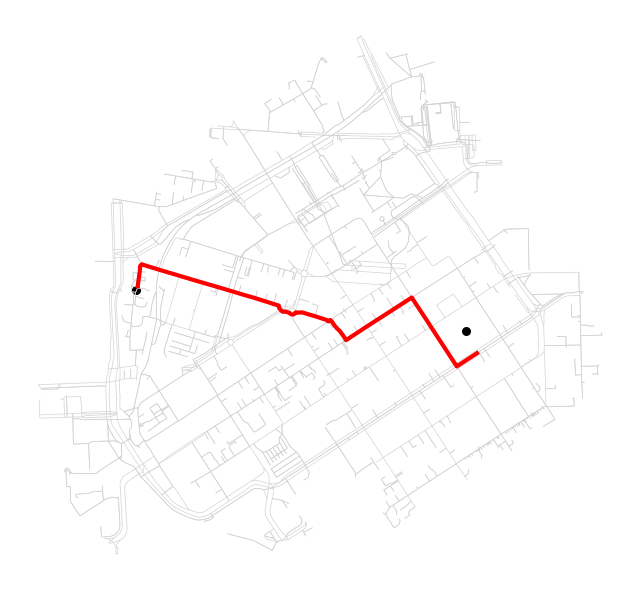

In [5]:
nodes, edges = osmnx.graph_to_gdfs(graph)

ax = edges.plot(color="lightgrey", linewidth=0.5, figsize=(8, 8))
route.plot(ax=ax, color="red", linewidth=3)
geopandas.GeoSeries([origin, destination], crs=route.crs).plot(ax=ax, color="black", markersize=30)
ax.set_axis_off()

## Step 2: reuse the functions

Nice! Now that the workflow is packed into functions, analysing another area
takes only two lines of code. Let’s find the bike route from the Physicum
building on Kumpula campus to the *Arabian rantapuisto* park by the sea. The
park lies a bit outside of Kumpula, so we use a larger buffer:

In [6]:
graph_kumpula = get_network("Kumpula, Helsinki, Finland", buffer_m=1500)
route_kumpula = shortest_route(graph_kumpula, "Physicum, Helsinki", "Arabian rantapuisto, Helsinki")
route_kumpula.drop(columns="geometry")

,origin,destination,length_m
0,"Physicum, Helsinki","Arabian rantapuisto, Helsinki",1402.57648


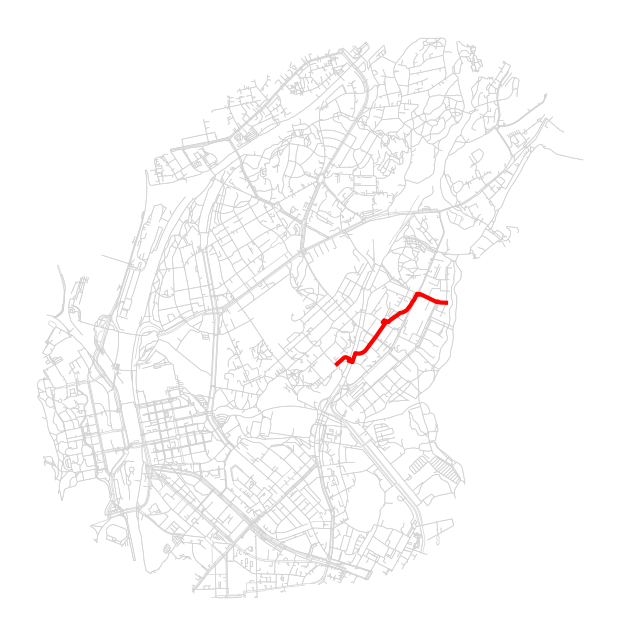

In [7]:
nodes, edges = osmnx.graph_to_gdfs(graph_kumpula)

ax = edges.plot(color="lightgrey", linewidth=0.5, figsize=(8, 8))
route_kumpula.plot(ax=ax, color="red", linewidth=3)
ax.set_axis_off()

## AI-use log

Whenever you use an AI assistant in this course (in exercises, only where a
task is marked **AI-LLM OK**, see the [course guidelines on AI
tools](https://autogis-site.readthedocs.io/en/latest/course-info/ai-tools.html)),
keep a short log of what you did. For this notebook, it could look like this:

| Step | What I asked | What I changed | How I checked it |
|------|--------------|----------------|------------------|
| 1 | Turn the lesson’s network workflow into `get_network()` and `shortest_route()` | Nothing | Ran it on the lesson’s example, checked route length against the straight-line distance, plotted the route |
| 2 | (no prompt) | – | Reused the functions for a second area |